This project develops a systematic multi-asset portfolio strategy that combines momentum-based signals with constrained mean-variance optimization in a realistic, out-of-sample setting.

The model separates alpha generation from capital allocation by using momentum to identify attractive assets and optimization to control risk, diversification and turnover. The strategy is implemented in a rolling framework with monthly rebalancing and daily return tracking to simulate real-world portfolio management.

In [1]:
# ==============================
# IMPORTS
# ==============================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8")

In [2]:
tickers = [

# Technology
"AAPL","MSFT","NVDA","GOOGL",

# Financials
"JPM","BAC","GS",

# Energy
"XOM","CVX",

# Healthcare
"UNH","MRK",

# Consumer
"AMZN","HD",

# Industrials
"CAT","GE",

# Diversifiers
"GLD","TLT","VNQ"


]

benchmark = "SPY"


In [137]:
# ===============================
# Data Collection
# ===============================

start = "2015-01-01"
end = "2024-01-01"

data = yf.download(tickers, start=start, end=end)["Close"]
returns = data.pct_change().dropna()

benchmark_data = yf.download("SPY", start=start, end=end)["Close"]
benchmark_returns = benchmark_data.pct_change().dropna()



[*********************100%***********************]  18 of 18 completed
[*********************100%***********************]  1 of 1 completed


In [139]:
# ==============================
# PARAMETERS
# ==============================
risk_free = 0.02
num_assets = len(tickers)

window = 252                # 1 year
rebalance_step = 21         # monthly
momentum_lookback = 252

bounds = tuple((0, 0.4) for _ in range(num_assets))
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

In [150]:
# ==============================
# FUNCTIONS
# ==============================
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol


def max_drawdown(series):
    cum = (1 + series).cumprod()
    peak = cum.cummax()
    return ((cum - peak) / peak).min()


def portfolio_summary(name, series):
    series = pd.Series(series).dropna()   # force clean Series

    log_ret = np.log1p(series)

    ann_return = float(np.exp(log_ret.mean() * 252) - 1)
    ann_vol = float(series.std() * np.sqrt(252))
    sharpe = float((ann_return - risk_free) / ann_vol)
    mdd = float(max_drawdown(series))

    return {
        "Strategy": name,
        "Return": ann_return,
        "Volatility": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd
    }

In [143]:
# ==============================
# ROLLING STRATEGY
# ==============================
rolling_returns = []
rolling_dates = []
weights_history = []

prev_weights = np.array([1/num_assets]*num_assets)

for i in range(window, len(returns), rebalance_step):

    train = returns.iloc[i-window:i]
    mean_r = train.mean() * 252
    cov_r = train.cov() * 252

    # stabilize covariance
    cov_r += np.eye(len(cov_r)) * 1e-6

    # --------------------------
    # MOMENTUM SIGNAL
    # --------------------------
    price_window = data.iloc[i-momentum_lookback:i]

    momentum = price_window.pct_change().mean() * 252
    momentum = momentum.clip(lower=0)

    if momentum.sum() == 0:
        momentum_weights = np.array([1/num_assets]*num_assets)
    else:
        momentum_weights = momentum / momentum.sum()

    # --------------------------
    # OPTIMIZATION
    # --------------------------
    def objective(w):
        ret, vol = portfolio_performance(w, mean_r, cov_r)

        if not np.isfinite(ret) or not np.isfinite(vol) or vol <= 1e-8:
            return 1e6

        turnover = np.sum(np.abs(w - prev_weights))
        cost = 0.001 * turnover

        return -(ret - risk_free) / vol + cost

    res = minimize(
        objective,
        prev_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 50}
    )

    if res.success and np.all(np.isfinite(res.x)):
        opt_weights = res.x
    else:
        opt_weights = prev_weights.copy()

    # --------------------------
    # FINAL WEIGHTS
    # --------------------------
    final_weights = 0.5 * opt_weights + 0.5 * momentum_weights
    final_weights /= final_weights.sum()

    weights_history.append(final_weights)

    # --------------------------
    # APPLY WEIGHTS DAILY
    # --------------------------
    for j in range(i, min(i + rebalance_step, len(returns))):
        daily_ret = np.dot(final_weights, returns.iloc[j])
        rolling_returns.append(daily_ret)
        rolling_dates.append(returns.index[j])

    prev_weights = final_weights

rolling_returns = pd.Series(rolling_returns, index=rolling_dates)
rolling_cum = (1 + rolling_returns).cumprod()

In [152]:
# ==============================
# BASELINES
# ==============================
equal_weights = np.array([1/num_assets]*num_assets)
equal_returns = returns.dot(equal_weights)


aligned_equal = equal_returns.loc[rolling_returns.index]
aligned_benchmark = benchmark_returns.loc[rolling_returns.index]

In [156]:
# ==============================
# PERFORMANCE SUMMARY
# ==============================
summary = pd.DataFrame([
    portfolio_summary("Momentum + Optimization", rolling_returns),
    portfolio_summary("Equal Weight", aligned_equal),
    portfolio_summary("Benchmark (SPY)", aligned_benchmark['SPY'])
])

print(summary)

                  Strategy    Return  Volatility    Sharpe  Max Drawdown
0  Momentum + Optimization  0.214065    0.185245  1.047614     -0.219568
1             Equal Weight  0.195713    0.184358  0.953108     -0.324371
2          Benchmark (SPY)  0.133722    0.183967  0.618167     -0.337173


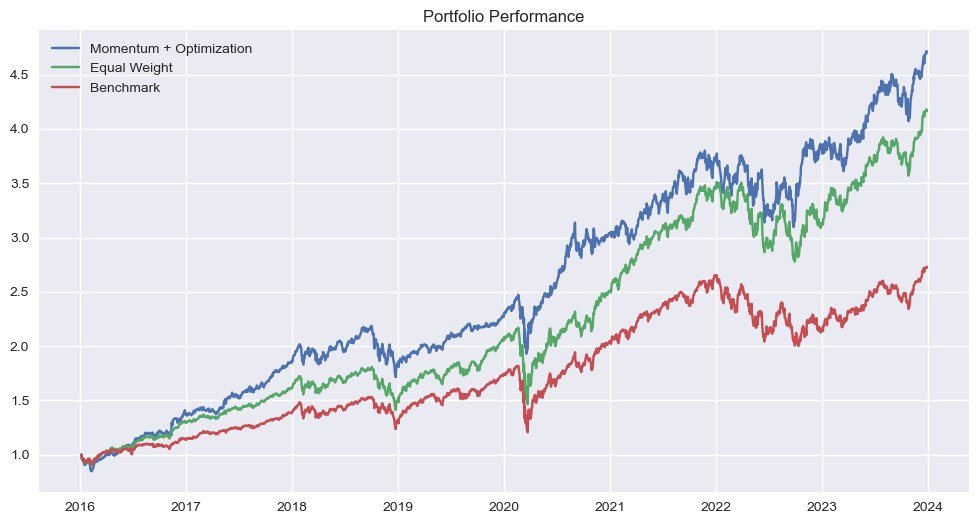

In [158]:
# ==============================
# PERFORMANCE PLOT
# ==============================
plt.figure(figsize=(12,6))

plt.plot(rolling_cum, label="Momentum + Optimization")
plt.plot((1+aligned_equal).cumprod(), label="Equal Weight")
plt.plot((1+aligned_benchmark).cumprod(), label="Benchmark")

plt.legend()
plt.title("Portfolio Performance")
plt.show()

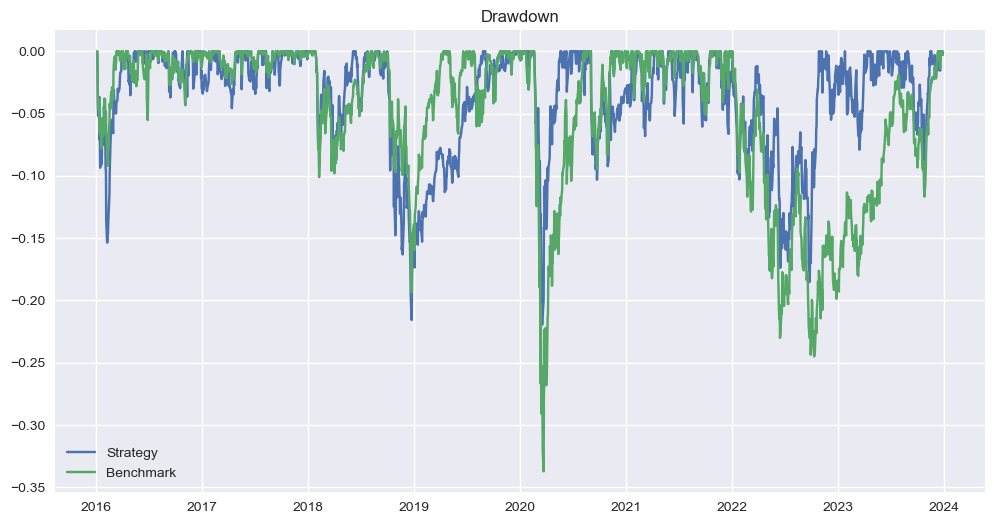

In [160]:
# ==============================
# DRAWDOWN
# ==============================
def compute_drawdown(series):
    cum = (1 + series).cumprod()
    peak = cum.cummax()
    return (cum - peak) / peak

strategy_dd = compute_drawdown(rolling_returns)
benchmark_dd = compute_drawdown(aligned_benchmark)

plt.figure(figsize=(12,6))
plt.plot(strategy_dd, label="Strategy")
plt.plot(benchmark_dd, label="Benchmark")
plt.legend()
plt.title("Drawdown")
plt.show()

In [162]:
# ==============================
# RISK CONTRIBUTION
# ==============================
def risk_contribution(weights, cov_matrix):
    port_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    marginal = np.dot(cov_matrix, weights)
    return weights * marginal / port_var

last_cov = returns.iloc[-window:].cov() * 252
last_weights = weights_history[-1]

rc = risk_contribution(last_weights, last_cov)

rc_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": last_weights,
    "Risk Contribution": rc
})

print(rc_df)

        Asset        Weight  Risk Contribution
Ticker                                        
AAPL     AAPL  3.738961e-02       2.490306e-02
AMZN     MSFT  7.399770e-02       8.162067e-02
BAC      NVDA  0.000000e+00       0.000000e+00
CAT     GOOGL  1.857630e-02       9.137397e-03
CVX       JPM  0.000000e+00       0.000000e+00
GE        BAC  2.737295e-01       2.439854e-01
GLD        GS  2.012166e-01       1.710211e-02
GOOGL     XOM  3.934482e-02       3.685181e-02
GS        CVX  0.000000e+00       0.000000e+00
HD        UNH  7.496276e-03       3.554766e-03
JPM       MRK  2.871510e-02       1.254508e-02
MRK      AMZN  1.168103e-03      -1.517857e-05
MSFT       HD  6.403156e-02       5.767384e-02
NVDA      CAT  2.201054e-01       5.099556e-01
TLT        GE  1.727625e-16       2.677514e-17
UNH       GLD  2.910035e-02       5.220249e-04
VNQ       TLT  4.688822e-03       2.137012e-03
XOM       VNQ  4.398180e-04       2.646781e-05


In [164]:
# ==============================
# BETA
# ==============================
aligned_strategy = rolling_returns
aligned_market = aligned_benchmark['SPY']

covariance = np.cov(aligned_strategy, aligned_market)[0][1]
market_var = np.var(aligned_market)

beta = covariance / market_var

print("Portfolio Beta:", beta)

Portfolio Beta: 0.775582797265033


Correlation with Benchmark (SPY): 0.7698511332678551


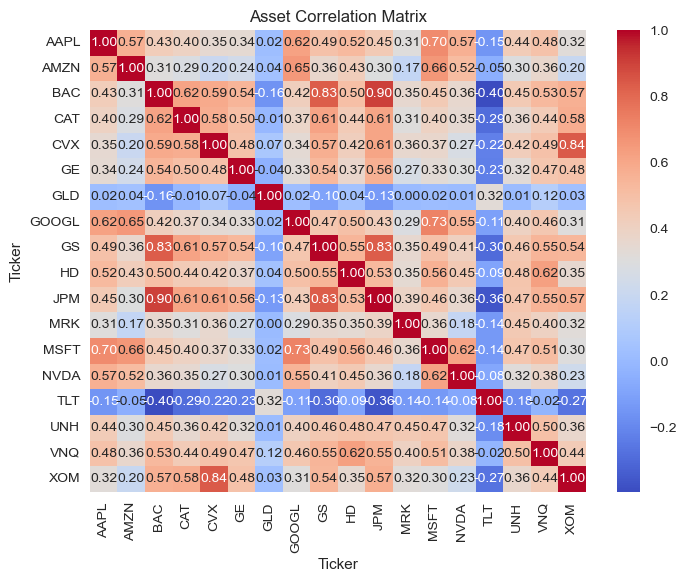

In [166]:
# ==============================
# CORRELATION ANALYSIS
# ==============================

# Strategy vs Benchmark
strategy_corr = rolling_returns.corr(aligned_benchmark['SPY'])
print("Correlation with Benchmark (SPY):", strategy_corr)

# Asset correlation matrix
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Asset Correlation Matrix")
plt.show()

In [168]:
# ==============================
# MOMENTUM SNAPSHOT
# ==============================
latest_momentum = (data.iloc[-1] / data.iloc[-252] - 1)

momentum_df = pd.DataFrame({
    "Asset": tickers,
    "Momentum": latest_momentum
}).sort_values(by="Momentum", ascending=False)

print(momentum_df)

        Asset  Momentum
Ticker                 
NVDA      CAT  2.392726
GE        BAC  0.958058
AMZN     MSFT  0.804942
GOOGL     XOM  0.579310
MSFT       HD  0.574102
AAPL     AAPL  0.493760
JPM       MRK  0.314895
CAT     GOOGL  0.256132
GS        CVX  0.158887
GLD        GS  0.132188
HD        UNH  0.111680
VNQ       TLT  0.110440
BAC      NVDA  0.047627
TLT        GE  0.016247
MRK      AMZN  0.011284
UNH       GLD  0.008523
XOM       VNQ -0.053173
CVX       JPM -0.130660


In [172]:
# ==============================
# PERFORMANCE COMPARISON
# ==============================

comparison = pd.DataFrame({
    "Strategy": portfolio_summary("Strategy", rolling_returns),
    "Benchmark": portfolio_summary("Benchmark", aligned_benchmark['SPY']),
    "Equal Weight": portfolio_summary("Equal", aligned_equal)
}).T

print(comparison)

# % Improvement vs Benchmark
improvement = pd.DataFrame({
    "Metric": ["Return", "Sharpe", "Max Drawdown"],
    "Improvement vs Benchmark": [
        comparison.loc["Strategy", "Return"] - comparison.loc["Benchmark", "Return"],
        comparison.loc["Strategy", "Sharpe"] - comparison.loc["Benchmark", "Sharpe"],
        abs(comparison.loc["Benchmark", "Max Drawdown"] - comparison.loc["Strategy", "Max Drawdown"])
    ]
})

print("\nImprovement vs Benchmark:")
print(improvement)

               Strategy    Return Volatility    Sharpe Max Drawdown
Strategy       Strategy  0.214065   0.185245  1.047614    -0.219568
Benchmark     Benchmark  0.133722   0.183967  0.618167    -0.337173
Equal Weight      Equal  0.195713   0.184358  0.953108    -0.324371

Improvement vs Benchmark:
         Metric  Improvement vs Benchmark
0        Return                  0.080343
1        Sharpe                  0.429447
2  Max Drawdown                  0.117604


## Summary

The strategy demonstrates improved risk-adjusted performance relative to the benchmark, achieving a higher Sharpe ratio (1.0 vs 0.6) while maintaining comparable volatility and reducing maximum drawdown (22% vs 34%).

These results highlight how combining simple, economically grounded signals with disciplined portfolio construction can produce more robust outcomes than relying on optimization or signals alone.